# Predicting Employee Attrition

---

## Research Question

Which employee attributes are most associated with attrition, and can attrition be predicted from workforce data.

---

## Problem Statement

Employee attrition creates hiring costs, knowledge loss, and lower team stability. Understanding the drivers of attrition helps a company target retention efforts before employees leave.

---

## Dataset Description

The dataset contains 1470 employee records with 35 workforce attributes including age, department, income, satisfaction scores, and attrition status. Each row represents one employee at a single point in time.

---

## Methodology

1. Data Collection
2. Data Cleaning
3. Exploratory Data Analysis
4. Statistical Analysis
5. Feature Engineering
6. Feature Encoding
7. Feature Scaling
8. Model Training
9. Cross Validation
10. Hyperparameter Tuning
11. Model Evaluation
12. Shap Interpretation

---

## Project Implementation

The steps below follow the same order and names used in the methodology section.

### 1. Data Collection

In [1]:
# Import libraries for step one
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import shap

In [2]:
# Set shared plot style for step one
PRIMARY = '#1f2933'
MUTED = '#7b8794'
ACCENT = '#2f6690'
ACCENT_ALERT = '#c9564f'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlecolor'] = PRIMARY
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.labelcolor'] = MUTED
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['xtick.color'] = MUTED
mpl.rcParams['ytick.color'] = MUTED

In [3]:
# Load dataset for step one collection
df = pd.read_csv('attrition_dataset.csv')
df.columns = df.columns.str.strip()
print('Row count', df.shape[0])
print('Column count', df.shape[1])
df.head()

Row count 1470
Column count 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### 2. Data Cleaning

In [4]:
# Check data quality for step two
missing_total = df.isna().sum().sum()
duplicate_total = df.duplicated().sum()
print('Missing value count', missing_total)
print('Duplicate row count', duplicate_total)

Missing value count 0
Duplicate row count 0


In [5]:
# Create title case labels for step two
df['DepartmentDisplay'] = df['Department'].str.title()
df['JobRoleDisplay'] = df['JobRole'].str.title()
df['GenderDisplay'] = df['Gender'].str.title()
df['OverTimeDisplay'] = df['OverTime'].map({'Yes': 'Overtime', 'No': 'No Overtime'})
df['AttritionDisplay'] = df['Attrition'].map({'Yes': 'Attrition', 'No': 'Retained'})
print('Step two complete, display labels created')

Step two complete, display labels created


### 3. Exploratory Data Analysis

In [6]:
# Prepare department summary for step three
dept_summary = df.groupby('DepartmentDisplay')['Attrition'].apply(
    lambda s: (s == 'Yes').mean() * 100
).sort_values()

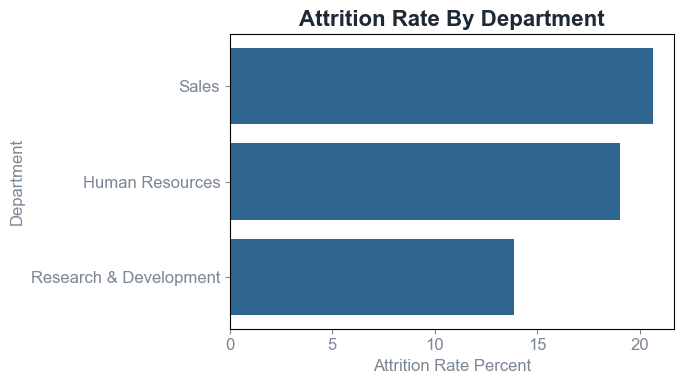

In [7]:
# Plot department attrition rates for step three
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(dept_summary.index, dept_summary.values, color=ACCENT)
ax.set_title('Attrition Rate By Department')
ax.set_xlabel('Attrition Rate Percent')
ax.set_ylabel('Department')
plt.tight_layout()
plt.show()

In [8]:
# Prepare job role summary for step three
role_summary = df.groupby('JobRoleDisplay')['Attrition'].apply(
    lambda s: (s == 'Yes').mean() * 100
).sort_values()

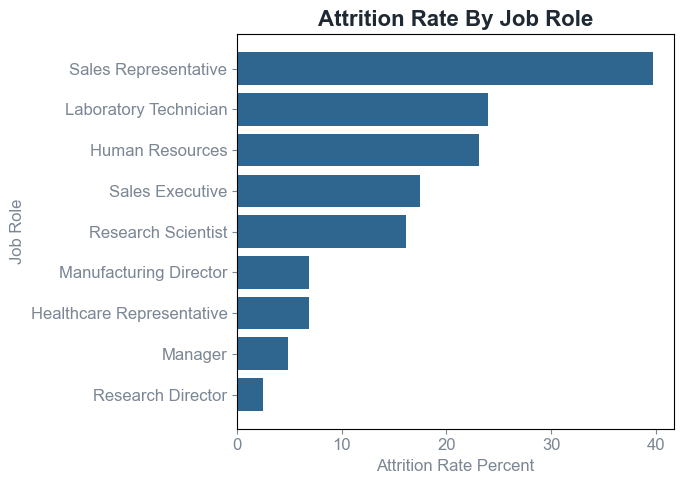

In [9]:
# Plot job role attrition rates for step three
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(role_summary.index, role_summary.values, color=ACCENT)
ax.set_title('Attrition Rate By Job Role')
ax.set_xlabel('Attrition Rate Percent')
ax.set_ylabel('Job Role')
plt.tight_layout()
plt.show()

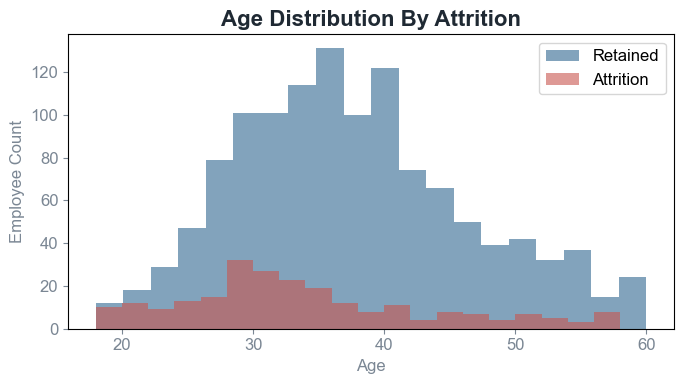

Step three complete, demographic patterns plotted


In [10]:
# Plot age distribution for step three
fig, ax = plt.subplots(figsize=(7, 4))
for label, color in [('Retained', ACCENT), ('Attrition', ACCENT_ALERT)]:
    subset = df[df['AttritionDisplay'] == label]
    ax.hist(subset['Age'], bins=20, alpha=0.6, label=label, color=color)
ax.set_title('Age Distribution By Attrition')
ax.set_xlabel('Age')
ax.set_ylabel('Employee Count')
ax.legend()
plt.tight_layout()
plt.show()
print('Step three complete, demographic patterns plotted')

### 4. Statistical Analysis

In [11]:
# Run income comparison test for step four
income_yes = df.loc[df['Attrition'] == 'Yes', 'MonthlyIncome']
income_no = df.loc[df['Attrition'] == 'No', 'MonthlyIncome']
income_stat, income_p = stats.ttest_ind(income_yes, income_no, equal_var=False)
print(f'Independent t test for monthly income, statistic {income_stat:.3f}, p value {income_p:.3f}')

Independent t test for monthly income, statistic -7.483, p value 0.000


In [12]:
# Run overtime association test for step four
overtime_table = pd.crosstab(df['OverTimeDisplay'], df['AttritionDisplay'])
chi_stat, chi_p, chi_dof, chi_expected = stats.chi2_contingency(overtime_table)
print(f'Chi square test for overtime and attrition, statistic {chi_stat:.3f}, p value {chi_p:.3f}')
print('Step four complete, statistical analysis finished')

Chi square test for overtime and attrition, statistic 87.564, p value 0.000
Step four complete, statistical analysis finished


### 5. Feature Engineering

In [13]:
# Create target flag for step five
df['AttritionFlag'] = (df['Attrition'] == 'Yes').astype(int)

In [14]:
# Create derived ratios for step five
df['TenureRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['IncomePerJobLevel'] = df['MonthlyIncome'] / df['JobLevel']
print('Step five complete, engineered features created')

Step five complete, engineered features created


### 6. Feature Encoding

In [15]:
# One hot encode categories for step six
categorical_cols = ['Department', 'JobRole', 'Gender', 'MaritalStatus', 'OverTime',
                     'EducationField', 'BusinessTravel']
model_df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
drop_cols = ['Attrition', 'AttritionDisplay', 'DepartmentDisplay', 'JobRoleDisplay',
             'GenderDisplay', 'OverTimeDisplay', 'Over18', 'EmployeeCount', 'StandardHours']
feature_cols = [c for c in model_df.columns if c not in drop_cols + ['AttritionFlag']]
X = model_df[feature_cols]
y = model_df['AttritionFlag']
print('Feature count after encoding', X.shape[1])

Feature count after encoding 47


### 7. Feature Scaling

In [16]:
# Split data for step seven scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# Scale features for step seven
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)
print('Training rows', X_train_scaled.shape[0])
print('Testing rows', X_test_scaled.shape[0])

Training rows 1176
Testing rows 294


### 8. Model Training

In [18]:
# Train baseline model for step eight
baseline_model = RandomForestClassifier(n_estimators=200, random_state=42)
baseline_model.fit(X_train_scaled, y_train)
print('Step eight complete, baseline model trained')

Step eight complete, baseline model trained


### 9. Cross Validation

In [19]:
# Run cross validation for step nine
cv_scores = cross_val_score(baseline_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Cross validation accuracy, mean {cv_scores.mean():.3f}, standard deviation {cv_scores.std():.3f}')
print('Step nine complete, cross validation finished')

Cross validation accuracy, mean 0.862, standard deviation 0.009
Step nine complete, cross validation finished


### 10. Hyperparameter Tuning

In [20]:
# Search hyperparameters for step ten
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}
search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=1,
)
search.fit(X_train_scaled, y_train)
tuned_model = search.best_estimator_
print('Best hyperparameters found', search.best_params_)
print('Step ten complete, hyperparameter tuning finished')

Best hyperparameters found {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}
Step ten complete, hyperparameter tuning finished


### 11. Model Evaluation

In [21]:
# Score tuned model for step eleven
y_pred = tuned_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'Tuned model results, accuracy {accuracy:.3f}, precision {precision:.3f}, recall {recall:.3f}, f1 score {f1:.3f}')

Tuned model results, accuracy 0.837, precision 0.455, recall 0.106, f1 score 0.172


In [22]:
# Prepare confusion matrix for step eleven
conf_matrix = confusion_matrix(y_test, y_pred)

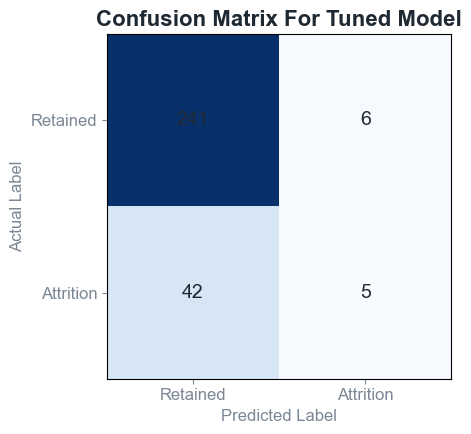

Step eleven complete, model evaluation finished


In [23]:
# Plot confusion matrix for step eleven
fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(conf_matrix, cmap='Blues')
labels = ['Retained', 'Attrition']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
for i in range(2):
    for j in range(2):
        ax.text(j, i, conf_matrix[i, j], ha='center', va='center', color=PRIMARY, fontsize=14)
ax.set_title('Confusion Matrix For Tuned Model')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('Actual Label')
plt.tight_layout()
plt.show()
print('Step eleven complete, model evaluation finished')

### 12. Shap Interpretation

In [24]:
# Compute shap values for step twelve
explainer = shap.TreeExplainer(tuned_model)
shap_values = explainer.shap_values(X_test_scaled)
positive_class_values = shap_values[:, :, 1]
mean_abs_shap = pd.Series(
    np.abs(positive_class_values).mean(axis=0), index=feature_cols
).sort_values()
top_shap = mean_abs_shap.tail(12)

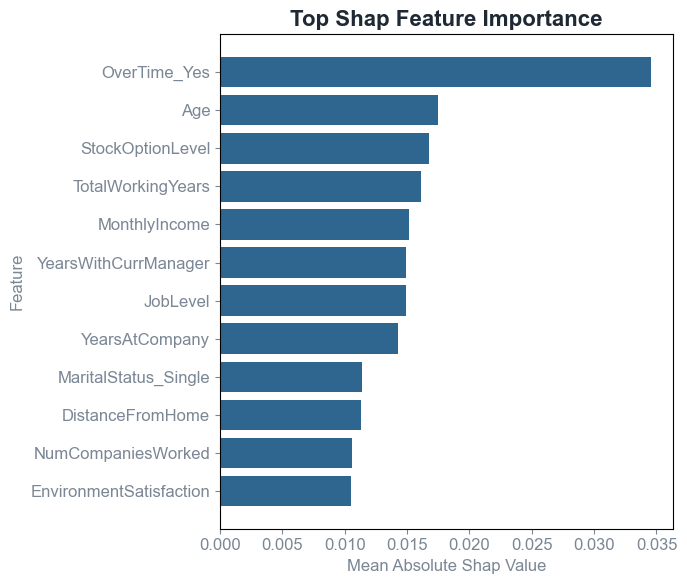

Step twelve complete, shap interpretation finished


In [25]:
# Plot shap feature importance for step twelve
fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top_shap.index, top_shap.values, color=ACCENT)
ax.set_title('Top Shap Feature Importance')
ax.set_xlabel('Mean Absolute Shap Value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()
print('Step twelve complete, shap interpretation finished')

---

## Limitation

The dataset represents a single company snapshot, so results may not generalize to other organizations. Some workforce factors such as manager quality or team culture are not captured in the data.

---

## Real World Uses

Human resource teams can use this type of analysis to flag employees at higher attrition risk and prioritize retention conversations. Leadership can use the department and role level patterns to guide staffing and compensation planning.

---

## Conclusion

Attrition is associated with several measurable factors including overtime, income, and job role. The tuned model captures this signal, and shap values show which features drive individual predictions.